## classification

In [1]:
import sklearn

In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Device count: {torch.cuda.device_count()}")

# If available, print device name
if torch.cuda.is_available():
    print(f"Device name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.8.0+cu129
CUDA available: True
CUDA version: 12.9
Device count: 1
Device name: NVIDIA GeForce RTX 4070 Ti


In [3]:
from sklearn.datasets import make_moons
import torch

In [4]:
import numpy as np

def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    
    model.to("cuda")

# Plot linear data or training and test and predictions (optional)
def plot_predictions(
    train_data, train_labels, test_data, test_labels, predictions=None
):
    """
  Plots linear training data and test data and compares predictions.
  """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})




In [5]:
n_samples = 1000

X, y = make_moons(n_samples, noise = 0.1, random_state = 12)

In [6]:
print(f"X: {X[:5]}")
print(f"\nY: {y[:5]}")

X: [[-0.04947672  0.49854496]
 [ 1.78136153 -0.16739184]
 [ 1.24665896 -0.39054157]
 [-0.32441836  0.89464105]
 [-0.44928192  0.9470479 ]]

Y: [1 1 1 0 0]


In [7]:
import pandas as pd

In [8]:
circles = pd.DataFrame({"X1" : X[:, 0], "X2" : X[:, 1], "label" : y})

circles.head(10)

,X1,X2,label
0,-0.049477,0.498545,1
1,1.781362,-0.167392,1
2,1.246659,-0.390542,1
3,-0.324418,0.894641,0
4,-0.449282,0.947048,0
5,1.394047,-0.250625,1
6,1.067279,-0.580582,1
7,1.467887,-0.194472,1
8,1.977678,0.254714,1
9,-0.695848,0.521315,0


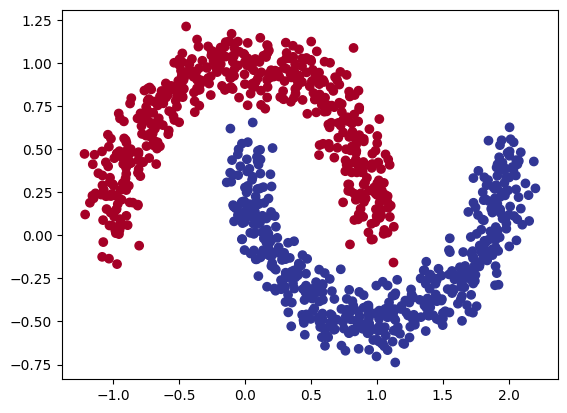

In [9]:
import matplotlib.pyplot as plt

plt.scatter(x = X[:, 0], y = X[:, 1], c = y, cmap = plt.cm.RdYlBu)

In [10]:
X.shape, y.shape

((1000, 2), (1000,))

In [11]:

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [13]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [14]:
n_samples

1000

## Model

In [15]:
from torch import nn

device = "cuda"

In [16]:
class MultyClassModel(nn.Module):
    def __init__(self, inputs, outputs, hidden_units = 256):
        
        super().__init__()
        
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features = inputs, out_features = hidden_units),
            nn.Sigmoid(),
            nn.Linear(in_features = hidden_units, out_features = hidden_units),
            nn.Sigmoid(),
            nn.Linear(in_features = hidden_units, out_features = outputs)
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

In [17]:
model_0 = MultyClassModel(inputs = 2, outputs = 1, hidden_units = 32).to(device)

model_0

MultyClassModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

model_0 = nn.Sequential(
    nn.Linear(in_features = 2, out_features = 16),
    nn.ReLU(),
    nn.Linear(in_features = 16, out_features = 1),
).to(device)

In [18]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [19]:
torch.manual_seed(42)

model_0.state_dict()

OrderedDict([('linear_layer_stack.0.weight',
              tensor([[ 0.4766, -0.6661],
                      [ 0.5471, -0.0852],
                      [ 0.4202, -0.2247],
                      [ 0.3435, -0.6803],
                      [-0.6680, -0.5908],
                      [ 0.1053, -0.6691],
                      [-0.3783, -0.1594],
                      [ 0.4085, -0.2957],
                      [ 0.0615,  0.0590],
                      [-0.3965, -0.3849],
                      [ 0.3956, -0.0073],
                      [ 0.0810,  0.2331],
                      [ 0.6675, -0.0443],
                      [ 0.3149,  0.1248],
                      [-0.4487,  0.3601],
                      [ 0.5969,  0.1655],
                      [-0.1462,  0.5074],
                      [-0.1309, -0.1276],
                      [ 0.7023, -0.0675],
                      [-0.1969,  0.4456],
                      [-0.3160,  0.4328],
                      [-0.0158, -0.0662],
                      [ 0.6219,

In [20]:
untrained_preds = model_0(X_test.to(device))
print(f"Predictions            =>   Lenght: {len(untrained_preds)},   Shape: {untrained_preds.shape}\n")
print(f"Test samples           =>   Lenght: {len(X_test)},   Shape: {X_test.shape}\n")
print(f"First 10 predictions   =>\n{torch.round(untrained_preds[:10])}\n\n")
print(f"First 10 lables        =>\n{y_test[:10]}")

Predictions            =>   Lenght: 200,   Shape: torch.Size([200, 1])

Test samples           =>   Lenght: 200,   Shape: torch.Size([200, 2])

First 10 predictions   =>
tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0', grad_fn=<RoundBackward0>)


First 10 lables        =>
tensor([0., 1., 1., 0., 1., 1., 0., 0., 0., 0.])


## Training

In [21]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 1)

In [22]:
def accuracy(y_real, y_pred):
    
    correct = torch.eq(y_real, y_pred).sum().item()
    acc = (correct/len(y_pred)) * 100

    return acc

In [23]:
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[0.1005],
        [0.0958],
        [0.0989],
        [0.0983],
        [0.0968]], device='cuda:0')

In [24]:
y_pred_sigmoid = torch.sigmoid(y_logits)
y_pred_sigmoid

tensor([[0.5251],
        [0.5239],
        [0.5247],
        [0.5246],
        [0.5242]], device='cuda:0')

In [25]:
y_preds = torch.round(y_pred_sigmoid)

y_pred_lables = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

print(torch.eq(y_pred_lables.squeeze(), y_preds.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([1., 1., 1., 1., 1.], device='cuda:0')

In [26]:
y_test[:5]

tensor([0., 1., 1., 0., 1.])

In [27]:
torch.manual_seed(0)
torch.cuda.manual_seed(42)

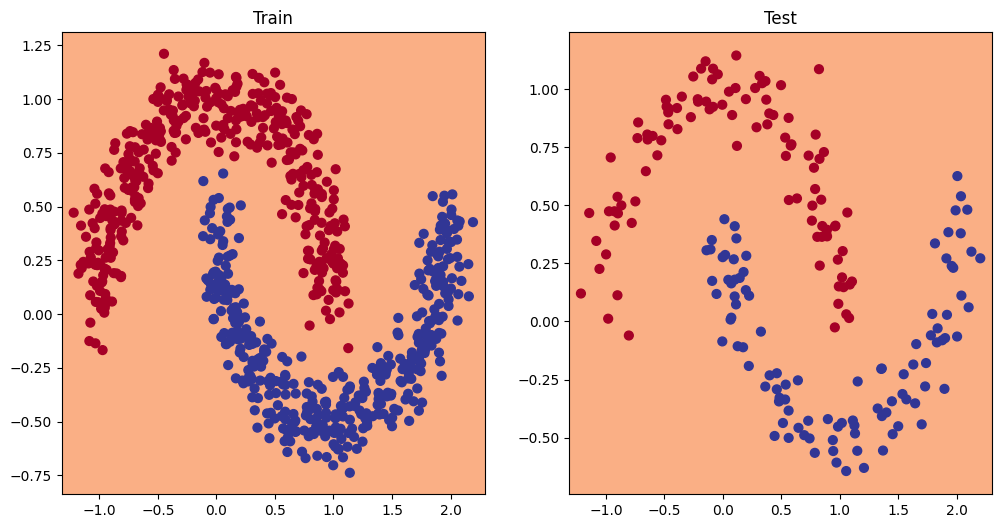

In [28]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [29]:

epochs = 10000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)


for epoch in range (epochs):
    
    model_0.train()
    
    
    y_logits = model_0(X_train).squeeze()


    
    y_pred = torch.round(torch.sigmoid(y_logits))


    #loss = loss_fn(torch.sigmoid(y_logits), y_train)

    
    loss = loss_fn(y_logits, y_train)

    acc = accuracy(y_real = y_train, y_pred = y_pred)


    optimizer.zero_grad()

    loss.backward()

    optimizer.step()
    

    model_0.eval()

    with torch.inference_mode():
        
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)

        test_acc =  accuracy(y_real = y_test, y_pred = test_pred)

    if epoch % 1000 == 0:
        print(f"Epoch: {epoch}  |  Loss: {loss: .5f}  | Acc: {acc: .2f}%  | Test loss: {test_loss: .5f}  | Test acc: {test_acc: 2f}%")
    

Epoch: 0  |  Loss:  0.69529  | Acc:  50.00%  | Test loss:  0.69510  | Test acc:  50.000000%
Epoch: 1000  |  Loss:  0.07921  | Acc:  97.62%  | Test loss:  0.08545  | Test acc:  98.000000%
Epoch: 2000  |  Loss:  0.01078  | Acc:  99.75%  | Test loss:  0.00865  | Test acc:  100.000000%
Epoch: 3000  |  Loss:  0.00642  | Acc:  99.88%  | Test loss:  0.00418  | Test acc:  100.000000%
Epoch: 4000  |  Loss:  0.00484  | Acc:  99.88%  | Test loss:  0.00277  | Test acc:  100.000000%
Epoch: 5000  |  Loss:  0.00398  | Acc:  99.88%  | Test loss:  0.00214  | Test acc:  100.000000%
Epoch: 6000  |  Loss:  0.00341  | Acc:  99.88%  | Test loss:  0.00180  | Test acc:  100.000000%
Epoch: 7000  |  Loss:  0.00301  | Acc:  100.00%  | Test loss:  0.00160  | Test acc:  100.000000%
Epoch: 8000  |  Loss:  0.00269  | Acc:  100.00%  | Test loss:  0.00147  | Test acc:  100.000000%
Epoch: 9000  |  Loss:  0.00244  | Acc:  100.00%  | Test loss:  0.00138  | Test acc:  100.000000%


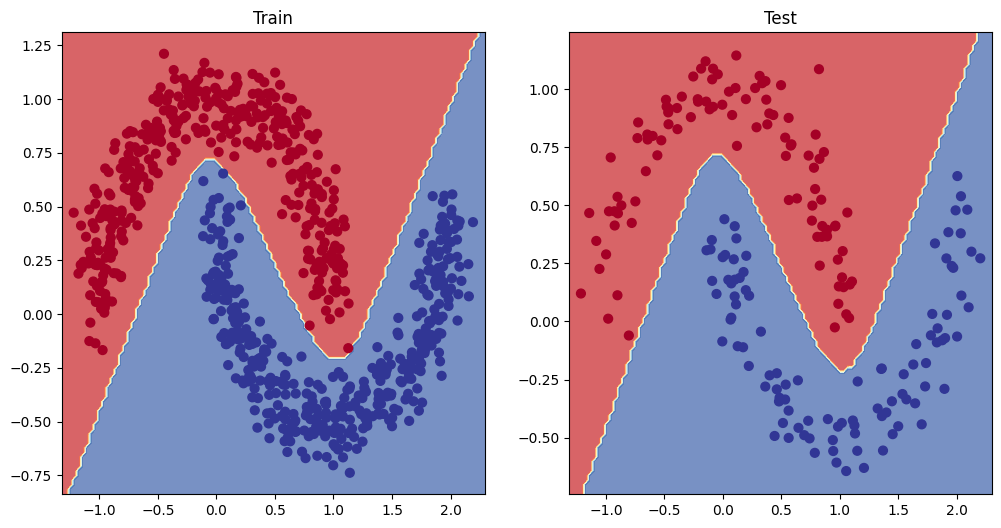

In [30]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train.cpu(), y_train.cpu())
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test.cpu(), y_test.cpu())